# W1-D1: Metric Anomaly Detection — Assignment
## Phase 1: EDA & Hiểu Data

### Cell 1 — Import thư viện
Đây là những thư viện chúng ta cần:
- `pandas` — đọc CSV, xử lý bảng dữ liệu
- `numpy` — tính toán số học (mean, std, log...)
- `matplotlib / seaborn` — vẽ đồ thị
- `scipy.stats` — tính skewness
- `statsmodels` — vẽ ACF (autocorrelation)
- `json` — đọc file label anomaly

In [2]:
!pip install statsmodels scikit-learn scipy seaborn joblib

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 8.3 MB/s eta 0:00:02
   ---------------------------------------- 9.6/9.6 MB 37.3 MB/s  0:00:00
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [patsy]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ -------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
import json
import warnings
warnings.filterwarnings('ignore')

# Làm cho đồ thị đẹp hơn
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(' Import xong!')

 Import xong!


### Cell 2 — Load data
Đọc file CSV vào pandas DataFrame.

**Lưu ý:** Đổi `DATA_PATH` và `LABELS_PATH` nếu file của bạn ở chỗ khác.

In [2]:
# ==== ĐỔI PATH NẾU CẦN ====
DATA_PATH   = r'C:\Users\AdminPC\Downloads\aiops-4-w1day-1\machine_temperature_system_failure.csv'
LABELS_PATH = r'C:\Users\AdminPC\Downloads\aiops-4-w1day-1\combined_labels.json'
# ==========================

# Đọc CSV
df = pd.read_csv(DATA_PATH)

# Cột 'timestamp' đang là string → chuyển thành kiểu datetime để pandas hiểu
df['timestamp'] = pd.to_datetime(df['timestamp'])
\
# Đặt timestamp làm index (giống trục X của đồ thị)
df = df.set_index('timestamp')

# Xem 5 dòng đầu
print(f'Shape: {df.shape}  →  {df.shape[0]} data points, {df.shape[1]} cột')
print(f'Từ: {df.index.min()}  →  Đến: {df.index.max()}')
df.head()

Shape: (22695, 1)  →  22695 data points, 1 cột
Từ: 2013-12-02 21:15:00  →  Đến: 2014-02-19 15:25:00


,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836


### Cell 3 — Load ground truth labels
File `combined_labels.json` chứa timestamp của các anomaly thật.
Chúng ta sẽ dùng để tính precision/recall ở Phase 2.

In [25]:
# Đọc file JSON chứa labels
with open(LABELS_PATH, 'r') as f:
    all_labels = json.load(f)

# Key trong JSON là tên file — tìm key phù hợp
label_key = [k for k in all_labels.keys() if 'machine_temperature' in k][0]
anomaly_timestamps = pd.to_datetime(all_labels[label_key])

print(f'Key tìm được: {label_key}')
print(f'Số anomaly thật: {len(anomaly_timestamps)}')
print('Timestamps anomaly:')
for ts in anomaly_timestamps:
    print(f'  → {ts}')

# Tạo cột binary label: 1 = anomaly thật, 0 = bình thường
# Dùng tolerance 5 phút vì timestamp trong label có thể không khớp chính xác
df['is_anomaly'] = 0
for ts in anomaly_timestamps:
    mask = (df.index >= ts - pd.Timedelta('4h')) & (df.index <= ts + pd.Timedelta('4h'))
    df.loc[mask, 'is_anomaly'] = 1

print(f'\nSố điểm được đánh dấu anomaly trong df: {df["is_anomaly"].sum()}')

Key tìm được: realKnownCause/machine_temperature_system_failure.csv
Số anomaly thật: 4
Timestamps anomaly:
  → 2013-12-11 06:00:00
  → 2013-12-16 17:25:00
  → 2014-01-28 13:55:00
  → 2014-02-08 14:30:00

Số điểm được đánh dấu anomaly trong df: 388


### Cell 4 — Plot raw time series
Nhìn bằng mắt trước — đây là bước quan trọng nhất trong EDA.
Tìm: spike bất thường, trend tăng/giảm, pattern lặp lại theo ngày/tuần.

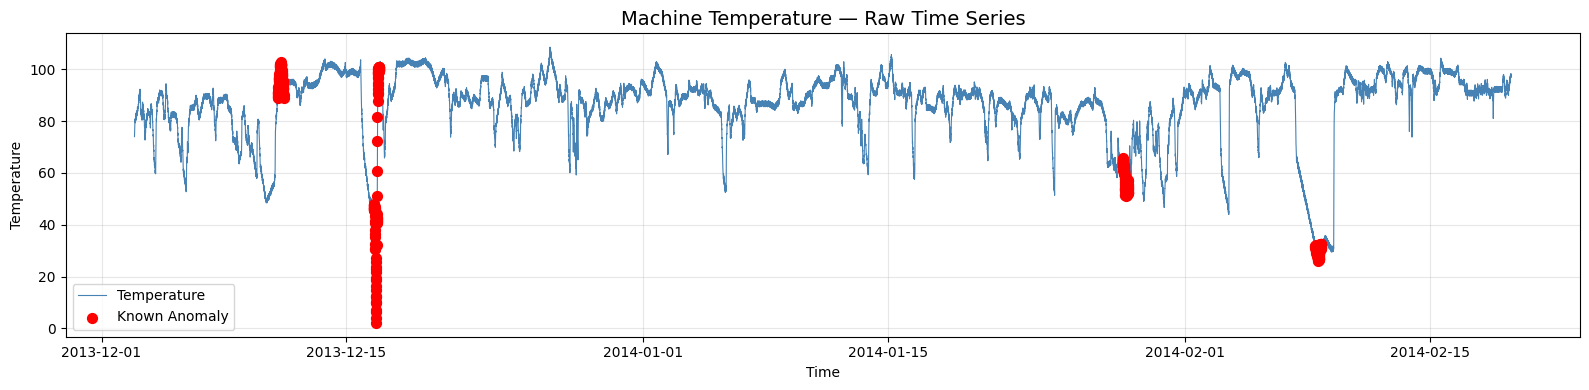

 Đã lưu: plot_raw_series.png


In [26]:
fig, ax = plt.subplots(figsize=(16, 4))

# Vẽ toàn bộ time series
ax.plot(df.index, df['value'], color='steelblue', linewidth=0.8, label='Temperature')

# Highlight các điểm anomaly thật bằng chấm đỏ
anomaly_points = df[df['is_anomaly'] == 1]
ax.scatter(anomaly_points.index, anomaly_points['value'],
           color='red', s=50, zorder=5, label='Known Anomaly')

ax.set_title('Machine Temperature — Raw Time Series', fontsize=14)
ax.set_xlabel('Time')
ax.set_ylabel('Temperature')
ax.legend()
plt.tight_layout()
plt.savefig('plot_raw_series.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Đã lưu: plot_raw_series.png')

### Cell 5 — Basic Statistics
Tính các thống kê cơ bản: mean, std, skewness, min, max.

**Skewness:**
- `|skew| < 0.5` → gần Gaussian → dùng 3σ OK
- `0.5 < |skew| < 1` → moderate skew → cẩn thận
- `|skew| > 1` → heavily skewed → KHÔNG dùng 3σ trực tiếp

In [27]:
series = df['value']

mean_val   = series.mean()
std_val    = series.std()
skew_val   = stats.skew(series)
min_val    = series.min()
max_val    = series.max()
median_val = series.median()

print('=' * 45)
print('       BASIC STATISTICS')
print('=' * 45)
print(f'  Count   : {len(series):,} data points')
print(f'  Mean    : {mean_val:.2f}')
print(f'  Median  : {median_val:.2f}')
print(f'  Std Dev : {std_val:.2f}')
print(f'  Min     : {min_val:.2f}')
print(f'  Max     : {max_val:.2f}')
print(f'  Skewness: {skew_val:.3f}')
print('=' * 45)

# Tự động nhận xét skewness
if abs(skew_val) < 0.5:
    print(' Gần Gaussian → 3σ có thể dùng được')
elif abs(skew_val) < 1.0:
    print('  Moderate skew → cẩn thận khi dùng 3σ, cân nhắc IQR')
else:
    print(' Heavily skewed → KHÔNG dùng 3σ, dùng IQR hoặc log transform')

       BASIC STATISTICS
  Count   : 22,695 data points
  Mean    : 85.93
  Median  : 89.41
  Std Dev : 13.75
  Min     : 2.08
  Max     : 108.51
  Skewness: -1.834
 Heavily skewed → KHÔNG dùng 3σ, dùng IQR hoặc log transform


### Cell 6 — Histogram + Density Plot
Nhìn hình dạng phân phối:
- **Bell curve đối xứng** → Gaussian
- **Đuôi dài bên phải** → right-skewed
- **Nhiều đỉnh (bimodal)** → có thể có 2 chế độ hoạt động khác nhau

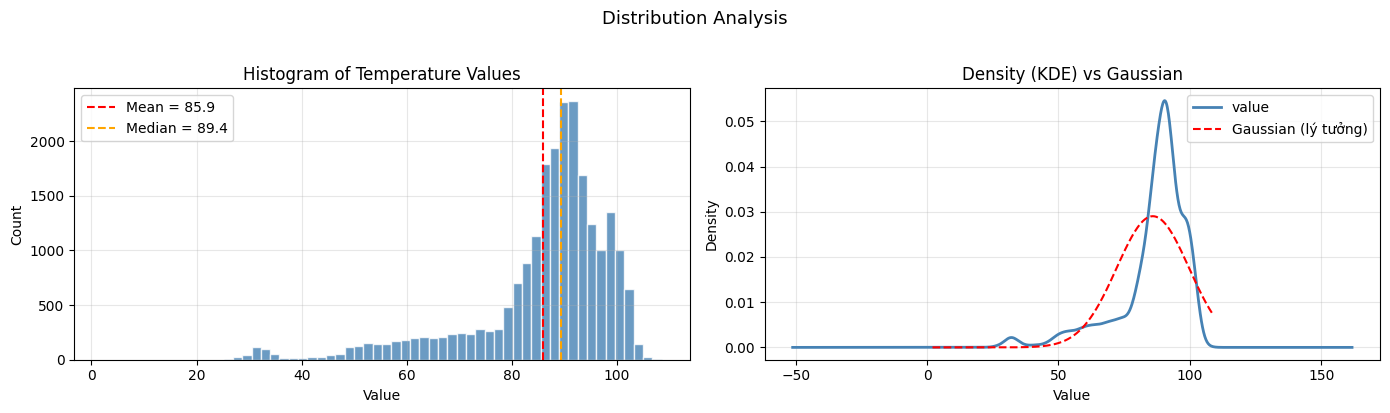

 Đã lưu: plot_distribution.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Panel trái: Histogram ---
axes[0].hist(series, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(mean_val,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean = {mean_val:.1f}')
axes[0].axvline(median_val, color='orange', linestyle='--', linewidth=1.5, label=f'Median = {median_val:.1f}')
axes[0].set_title('Histogram of Temperature Values')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Panel phải: KDE (Kernel Density Estimate) = đường cong mượt ---
# Mục đích: thấy hình dạng phân phối rõ hơn histogram
series.plot.kde(ax=axes[1], color='steelblue', linewidth=2)

# Vẽ đường Gaussian lý tưởng để so sánh
x = np.linspace(min_val, max_val, 300)
gaussian = stats.norm.pdf(x, mean_val, std_val)
axes[1].plot(x, gaussian, color='red', linestyle='--', linewidth=1.5, label='Gaussian (lý tưởng)')

axes[1].set_title('Density (KDE) vs Gaussian')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Distribution Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Đã lưu: plot_distribution.png')

### Cell 7 — ACF Plot (Autocorrelation)
ACF đo "data có giống chính nó ở N bước trước không".

- **Peak ở lag = 1440** → daily pattern với data 1-minute
- **Peak ở lag = 288** → daily pattern với data 5-minute
- **Không có peak rõ** → không có seasonal pattern

Kết quả này quyết định có dùng STL không và period bao nhiêu.

 Granularity data: mỗi 5 phút
   Period daily  = 288  (= 1 ngày)
   Period weekly = 2016 (= 7 ngày)


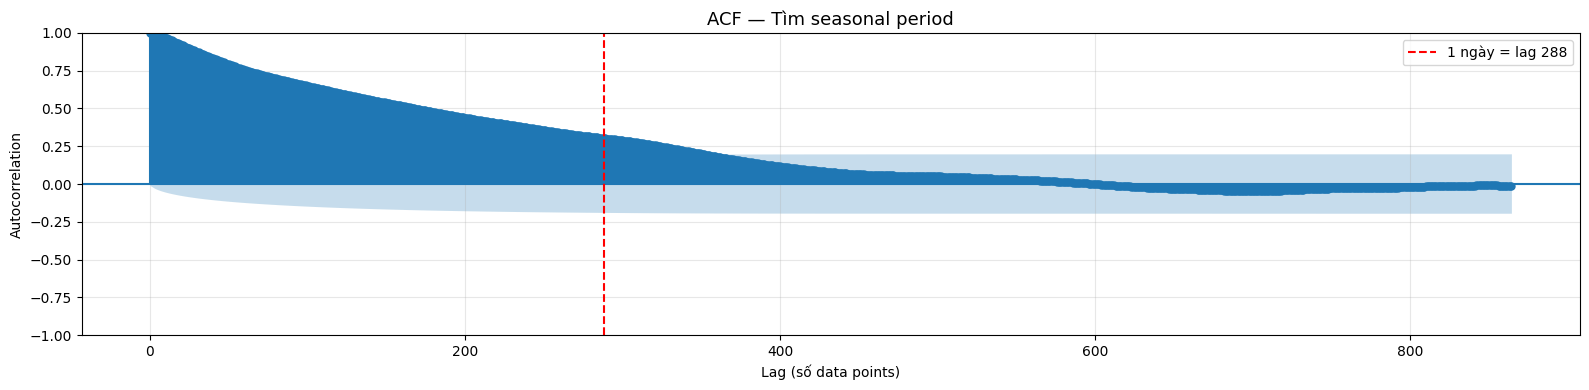

 Đã lưu: plot_acf.png


In [29]:
# Tính khoảng cách giữa 2 data point liên tiếp
time_diffs = df.index.to_series().diff().dropna()
freq_minutes = time_diffs.median().total_seconds() / 60
print(f' Granularity data: mỗi {freq_minutes:.0f} phút')

# Tính period theo daily cycle
period_daily  = int(24 * 60 / freq_minutes)
period_weekly = period_daily * 7
print(f'   Period daily  = {period_daily}  (= 1 ngày)')
print(f'   Period weekly = {period_weekly} (= 7 ngày)')

# Vẽ ACF — lags = 3 ngày để thấy cả daily và multi-day pattern
max_lags = min(period_daily * 3, len(series) // 2 - 1)

fig, ax = plt.subplots(figsize=(16, 4))
plot_acf(series, lags=max_lags, ax=ax, alpha=0.05)

# Đánh dấu vị trí period daily trên đồ thị
ax.axvline(period_daily, color='red', linestyle='--', linewidth=1.5,
           label=f'1 ngày = lag {period_daily}')
ax.set_title('ACF — Tìm seasonal period', fontsize=13)
ax.set_xlabel('Lag (số data points)')
ax.set_ylabel('Autocorrelation')
ax.legend()

plt.tight_layout()
plt.savefig('plot_acf.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Đã lưu: plot_acf.png')

### Cell 8 — Kết luận EDA
Tổng hợp tất cả quan sát → chọn phương pháp phù hợp.

In [30]:
print('=' * 55)
print('           KẾT LUẬN EDA — PHASE 1')
print('=' * 55)

print(f'\n1. PHÂN PHỐI:')
print(f'   Skewness = {skew_val:.3f}')
if abs(skew_val) < 0.5:
    print('   → Gần Gaussian, mean ≈ median')
    print('   → 3σ (rolling Z-score) phù hợp')
else:
    print(f'   → Skewed (mean={mean_val:.1f} vs median={median_val:.1f})')
    print('   → Nên dùng IQR hoặc log transform trước khi dùng 3σ')

print(f'\n2. SEASONAL PATTERN:')
print(f'   Data granularity: mỗi {freq_minutes:.0f} phút')
print(f'   Period daily = {period_daily} data points')
print('   → Xem ACF plot: nếu có peak ở lag ~' + str(period_daily) + ' → có daily pattern → dùng STL')
print('   → Nếu không có peak rõ → không seasonal → dùng 3σ hoặc EWMA')

print(f'\n3. STATIONARITY (nhìn raw plot):')
print('   → Nếu mean tương đối ổn định suốt series → stationary')
print('   → Nếu có xu hướng tăng/giảm → non-stationary → cần EWMA hoặc STL')

print(f'\n4. ĐỀ XUẤT PHƯƠNG PHÁP:')
print('   Detector 1 (Statistical): STL + 3σ trên residual')
print('   Lý do: data có thể có daily pattern → STL loại bỏ seasonal')
print('   trước → 3σ trên residual chính xác hơn trên raw data')
print()
print('   Detector 2 (ML): Isolation Forest với feature engineering')
print('   Lý do: không giả định distribution, handle multivariate,')
print('   phát hiện spike bất ngờ tốt hơn STL')
print('=' * 55)

# Lưu period để dùng ở Phase 2
PERIOD = period_daily
print(f'\n PERIOD = {PERIOD} (sẽ dùng cho STL ở Phase 2)')

           KẾT LUẬN EDA — PHASE 1

1. PHÂN PHỐI:
   Skewness = -1.834
   → Skewed (mean=85.9 vs median=89.4)
   → Nên dùng IQR hoặc log transform trước khi dùng 3σ

2. SEASONAL PATTERN:
   Data granularity: mỗi 5 phút
   Period daily = 288 data points
   → Xem ACF plot: nếu có peak ở lag ~288 → có daily pattern → dùng STL
   → Nếu không có peak rõ → không seasonal → dùng 3σ hoặc EWMA

3. STATIONARITY (nhìn raw plot):
   → Nếu mean tương đối ổn định suốt series → stationary
   → Nếu có xu hướng tăng/giảm → non-stationary → cần EWMA hoặc STL

4. ĐỀ XUẤT PHƯƠNG PHÁP:
   Detector 1 (Statistical): STL + 3σ trên residual
   Lý do: data có thể có daily pattern → STL loại bỏ seasonal
   trước → 3σ trên residual chính xác hơn trên raw data

   Detector 2 (ML): Isolation Forest với feature engineering
   Lý do: không giả định distribution, handle multivariate,
   phát hiện spike bất ngờ tốt hơn STL

 PERIOD = 288 (sẽ dùng cho STL ở Phase 2)


---
## Phase 2: Implement 2 Detectors

### Cell 9 — Helper: tính Precision / Recall / F1
Trước khi implement detector, cần hàm để đo kết quả.

- **TP** (True Positive): model báo anomaly, và đúng là anomaly thật
- **FP** (False Positive): model báo anomaly, nhưng thực ra bình thường (false alarm)
- **FN** (False Negative): model không báo, nhưng thực ra là anomaly thật (miss)
- **Precision** = TP / (TP + FP) → trong những gì model báo, bao nhiêu % đúng
- **Recall** = TP / (TP + FN) → trong anomaly thật, bao nhiêu % model bắt được

In [31]:
def evaluate(y_true, y_pred, name='Detector'):
    """
    Tính Precision, Recall, F1 và in kết quả đẹp.
    y_true, y_pred: array of 0/1 (1 = anomaly)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred).astype(int)

    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    fpr       = FP / (FP + TN) if (FP + TN) > 0 else 0  # False alarm rate

    print(f'\n{"─" * 40}')
    print(f'  {name}')
    print(f'{"─" * 40}')
    print(f'  TP={TP}  FP={FP}  FN={FN}  TN={TN}')
    print(f'  Precision       : {precision:.3f}')
    print(f'  Recall          : {recall:.3f}')
    print(f'  F1              : {f1:.3f}')
    print(f'  False alarm rate: {fpr:.4f}')
    print(f'{"─" * 40}')

    return {'precision': precision, 'recall': recall, 'f1': f1,
            'fp': FP, 'tp': TP, 'fn': FN, 'fpr': fpr}

print(' Hàm evaluate() đã sẵn sàng!')

 Hàm evaluate() đã sẵn sàng!


### Cell 10 — Detector 1: STL + 3σ
**Cách hoạt động:**
1. STL tách time series = trend + seasonal + residual
2. Residual = phần còn lại sau khi bỏ pattern bình thường
3. Dùng 3σ trên residual → anomaly = điểm có residual quá lớn

**Tại sao tốt hơn 3σ thẳng trên raw data:**
- Raw data có daily pattern → 3σ false alarm ở đỉnh/đáy daily
- Residual đã loại bỏ seasonal → 3σ chỉ trigger khi thực sự lạ

In [32]:
from statsmodels.tsa.seasonal import STL

print(f' Đang chạy STL với period={PERIOD}...')
print('   (Có thể mất 30-60 giây với dataset lớn)')

# Fit STL
# robust=True: outlier không ảnh hưởng tới việc ước lượng trend/seasonal
stl = STL(df['value'], period=PERIOD, robust=True)
stl_result = stl.fit()

# Lấy phần residual
residual = stl_result.resid

# Tính mean và std của residual
resid_mean = residual.mean()
resid_std  = residual.std()

# Áp dụng 3σ trên residual
THRESHOLD_STL = 3.0
stl_anomalies = np.abs(residual - resid_mean) > THRESHOLD_STL * resid_std

print(f' STL xong!')
print(f'   Residual mean = {resid_mean:.2f}, std = {resid_std:.2f}')
print(f'   Threshold = ±{THRESHOLD_STL * resid_std:.2f}')
print(f'   Số điểm bị đánh dấu anomaly: {stl_anomalies.sum()}')

 Đang chạy STL với period=288...
   (Có thể mất 30-60 giây với dataset lớn)
 STL xong!
   Residual mean = -1.07, std = 7.61
   Threshold = ±22.83
   Số điểm bị đánh dấu anomaly: 598


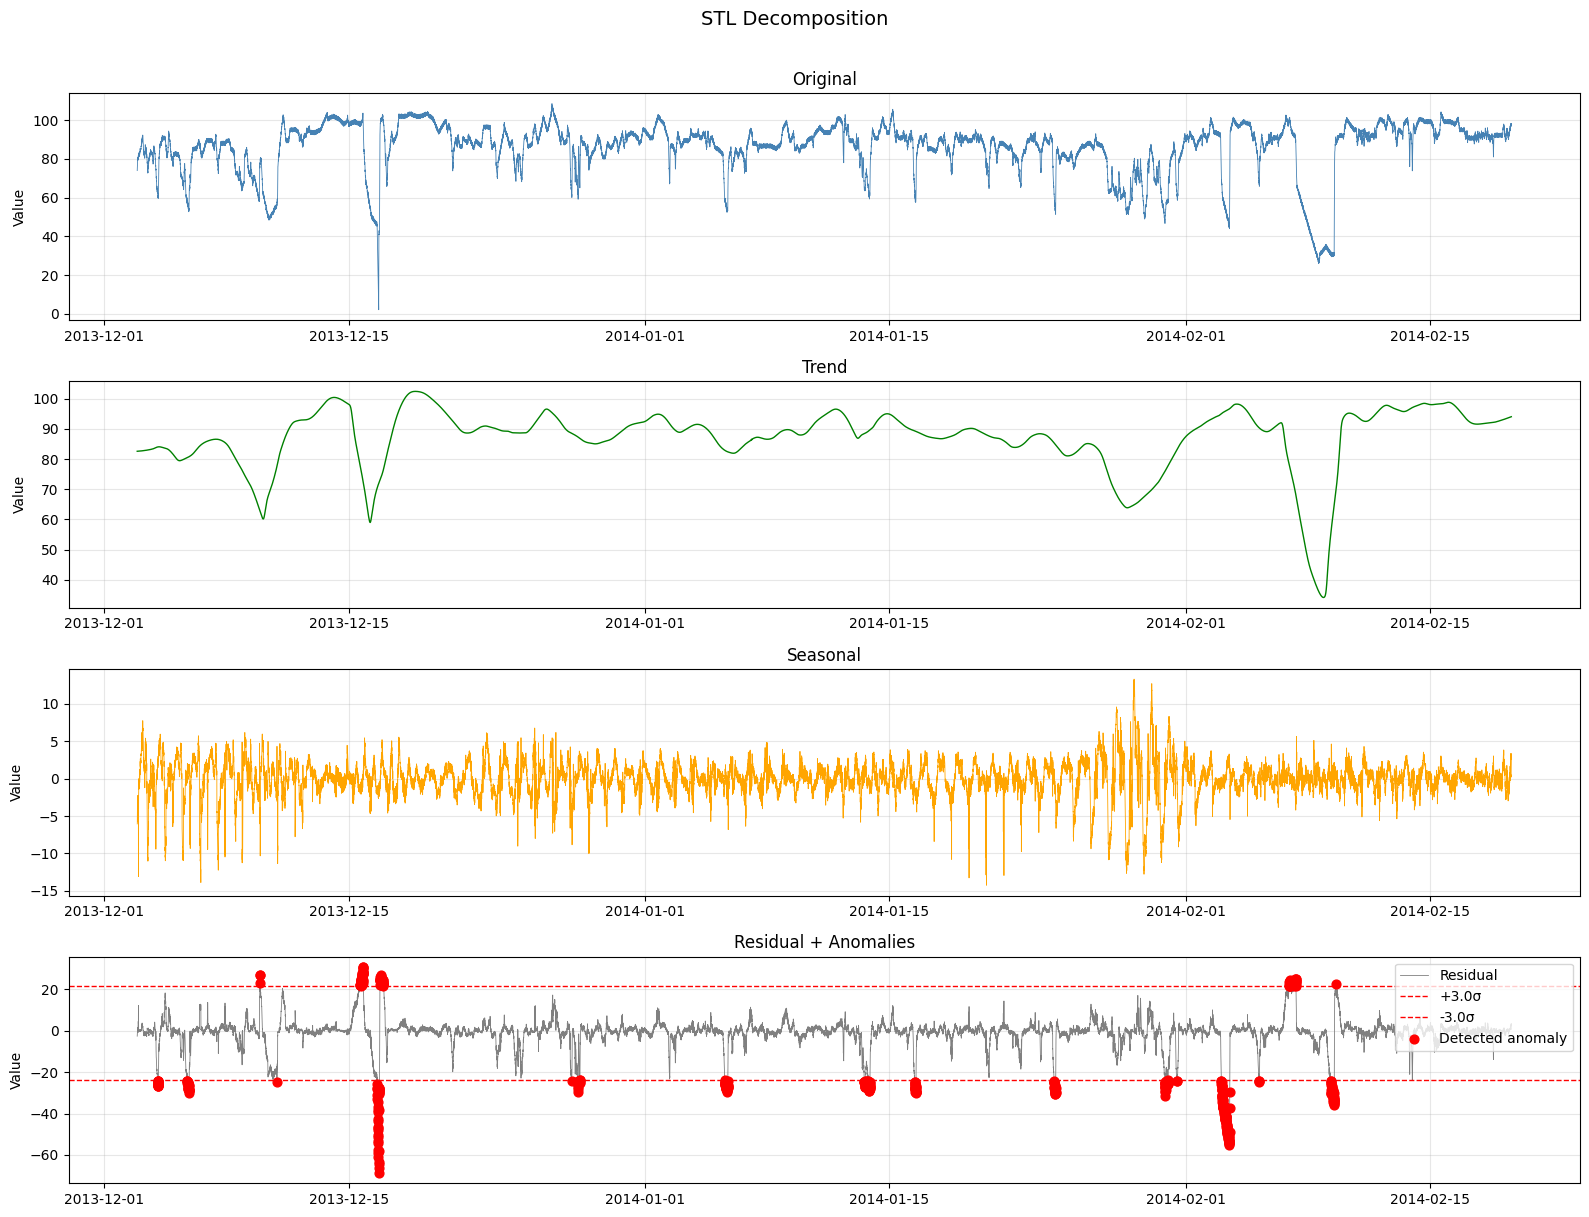

 Đã lưu: plot_stl_decomposition.png


In [33]:
# Vẽ STL decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

axes[0].plot(df.index, df['value'], color='steelblue', linewidth=0.6)
axes[0].set_title('Original')
axes[0].set_ylabel('Value')

axes[1].plot(df.index, stl_result.trend, color='green', linewidth=1)
axes[1].set_title('Trend')
axes[1].set_ylabel('Value')

axes[2].plot(df.index, stl_result.seasonal, color='orange', linewidth=0.6)
axes[2].set_title('Seasonal')
axes[2].set_ylabel('Value')

# Residual + highlight anomaly
axes[3].plot(df.index, residual, color='gray', linewidth=0.6, label='Residual')
axes[3].axhline(resid_mean + THRESHOLD_STL * resid_std, color='red',
                linestyle='--', linewidth=1, label=f'+{THRESHOLD_STL}σ')
axes[3].axhline(resid_mean - THRESHOLD_STL * resid_std, color='red',
                linestyle='--', linewidth=1, label=f'-{THRESHOLD_STL}σ')
axes[3].scatter(df.index[stl_anomalies], residual[stl_anomalies],
                color='red', s=40, zorder=5, label='Detected anomaly')
axes[3].set_title('Residual + Anomalies')
axes[3].set_ylabel('Value')
axes[3].legend(loc='upper right')

plt.suptitle('STL Decomposition', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Đã lưu: plot_stl_decomposition.png')

In [34]:
# Đánh giá Detector 1
y_true = df['is_anomaly'].values
y_pred_stl = stl_anomalies.astype(int).values

metrics_stl = evaluate(y_pred_stl, y_true, name='Detector 1: STL + 3σ')


────────────────────────────────────────
  Detector 1: STL + 3σ
────────────────────────────────────────
  TP=64  FP=324  FN=534  TN=21773
  Precision       : 0.165
  Recall          : 0.107
  F1              : 0.130
  False alarm rate: 0.0147
────────────────────────────────────────


### Cell 11 — Detector 2: Isolation Forest
**Cách hoạt động:**
1. Tạo feature table — mỗi data point có thêm context: rolling mean, std, rate of change...
2. Isolation Forest train trên feature table
3. Điểm nào "dễ tách" khỏi đám đông → anomaly score thấp → anomaly

**contamination** = tỷ lệ ước tính anomaly trong data (0.02 = 2%)

In [35]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def build_features(series, timestamps, window=60):
    """
    Biến 1 time series thành feature table.
    Mỗi row = 1 data point + 10 features về context xung quanh nó.
    """
    s = pd.Series(series.values, index=timestamps)

    features = pd.DataFrame({
        'value'           : s,
        'rolling_mean_1h' : s.rolling(window, min_periods=1).mean(),
        'rolling_std_1h'  : s.rolling(window, min_periods=1).std().fillna(0),
        'rolling_mean_4h' : s.rolling(window * 4, min_periods=1).mean(),
        'rate_of_change'  : s.diff().fillna(0),         # tăng/giảm so với 1 điểm trước
        'rate_5step'      : s.diff(5).fillna(0),         # so với 5 điểm trước
        'lag_1'           : s.shift(1).fillna(method='bfill'),
        'lag_60'          : s.shift(window).fillna(method='bfill'),
        'hour'            : s.index.hour,
        'is_weekend'      : (s.index.dayofweek >= 5).astype(int),
        'z_score'         : (s - s.rolling(window, min_periods=1).mean()) /
                            (s.rolling(window, min_periods=1).std().replace(0, 1e-10)),
    })
    return features


# Tạo feature table
window = max(12, int(60 / freq_minutes))  # window ~ 1 giờ
X = build_features(df['value'], df.index, window=window)
print(f'Feature table shape: {X.shape}')
print(f'Các feature: {list(X.columns)}')
X.head(3)

Feature table shape: (22695, 11)
Các feature: ['value', 'rolling_mean_1h', 'rolling_std_1h', 'rolling_mean_4h', 'rate_of_change', 'rate_5step', 'lag_1', 'lag_60', 'hour', 'is_weekend', 'z_score']


,value,rolling_mean_1h,rolling_std_1h,rolling_mean_4h,rate_of_change,rate_5step,lag_1,lag_60,hour,is_weekend,z_score
timestamp,,,,,,,,,,,
2013-12-02 21:15:00,73.967322,73.967322,0.000000,73.967322,0.00000,0.0,73.967322,73.967322,21,0,NaN
2013-12-02 21:20:00,74.935882,74.451602,0.684875,74.451602,0.96856,0.0,73.967322,73.967322,21,0,0.707107
2013-12-02 21:25:00,76.124162,75.009122,1.080284,75.009122,1.18828,0.0,74.935882,73.967322,21,0,1.032173


In [36]:
# Scale features về cùng range (IF nhạy với scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===== TUNE contamination =====
# Thử 3 giá trị, ghi lại precision/recall
contamination_values = [0.01, 0.02, 0.05]
tune_results = []

print('Tuning contamination parameter:')
print(f'{"contamination":>15}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}  {"FP":>6}')
print('─' * 55)

for cont in contamination_values:
    clf = IsolationForest(
        n_estimators=200,
        contamination=cont,
        random_state=42
    )
    clf.fit(X_scaled)
    preds = clf.predict(X_scaled)        # -1 = anomaly, 1 = normal
    preds_binary = (preds == -1).astype(int)

    TP = np.sum((preds_binary == 1) & (y_true == 1))
    FP = np.sum((preds_binary == 1) & (y_true == 0))
    FN = np.sum((preds_binary == 0) & (y_true == 1))

    prec = TP / (TP + FP) if (TP + FP) > 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    tune_results.append({'contamination': cont, 'precision': prec,
                         'recall': rec, 'f1': f1, 'fp': FP})
    print(f'{cont:>15.3f}  {prec:>10.3f}  {rec:>8.3f}  {f1:>8.3f}  {FP:>6}')

# Chọn contamination tốt nhất theo F1
best = max(tune_results, key=lambda x: x['f1'])
BEST_CONTAMINATION = best['contamination']
print(f'\n Best contamination = {BEST_CONTAMINATION} (F1={best["f1"]:.3f})')

Tuning contamination parameter:
  contamination   Precision    Recall        F1      FP
───────────────────────────────────────────────────────
          0.010       0.489     0.286     0.361     116
          0.020       0.315     0.369     0.340     311
          0.050       0.158     0.461     0.235     956

 Best contamination = 0.01 (F1=0.361)


In [37]:
import joblib

# Train final model với best contamination
clf_final = IsolationForest(
    n_estimators=200,
    contamination=BEST_CONTAMINATION,
    random_state=42
)
clf_final.fit(X_scaled)

# Lấy kết quả
if_preds  = clf_final.predict(X_scaled)
if_scores = clf_final.decision_function(X_scaled)  # càng âm = càng anomalous
if_anomalies = (if_preds == -1)  # True = anomaly

# Lưu model
joblib.dump(clf_final, 'isolation_forest_model.joblib')
joblib.dump(scaler,    'scaler.joblib')
print(f' Model saved: isolation_forest_model.joblib')
print(f'   Số điểm bị đánh dấu anomaly: {if_anomalies.sum()}')

# Đánh giá
y_pred_if = if_anomalies.astype(int)
metrics_if = evaluate(y_pred_if, y_true, name='Detector 2: Isolation Forest')

 Model saved: isolation_forest_model.joblib
   Số điểm bị đánh dấu anomaly: 227

────────────────────────────────────────
  Detector 2: Isolation Forest
────────────────────────────────────────
  TP=111  FP=277  FN=116  TN=22191
  Precision       : 0.286
  Recall          : 0.489
  F1              : 0.361
  False alarm rate: 0.0123
────────────────────────────────────────


### Cell 12 — So sánh 2 detector trên cùng 1 plot

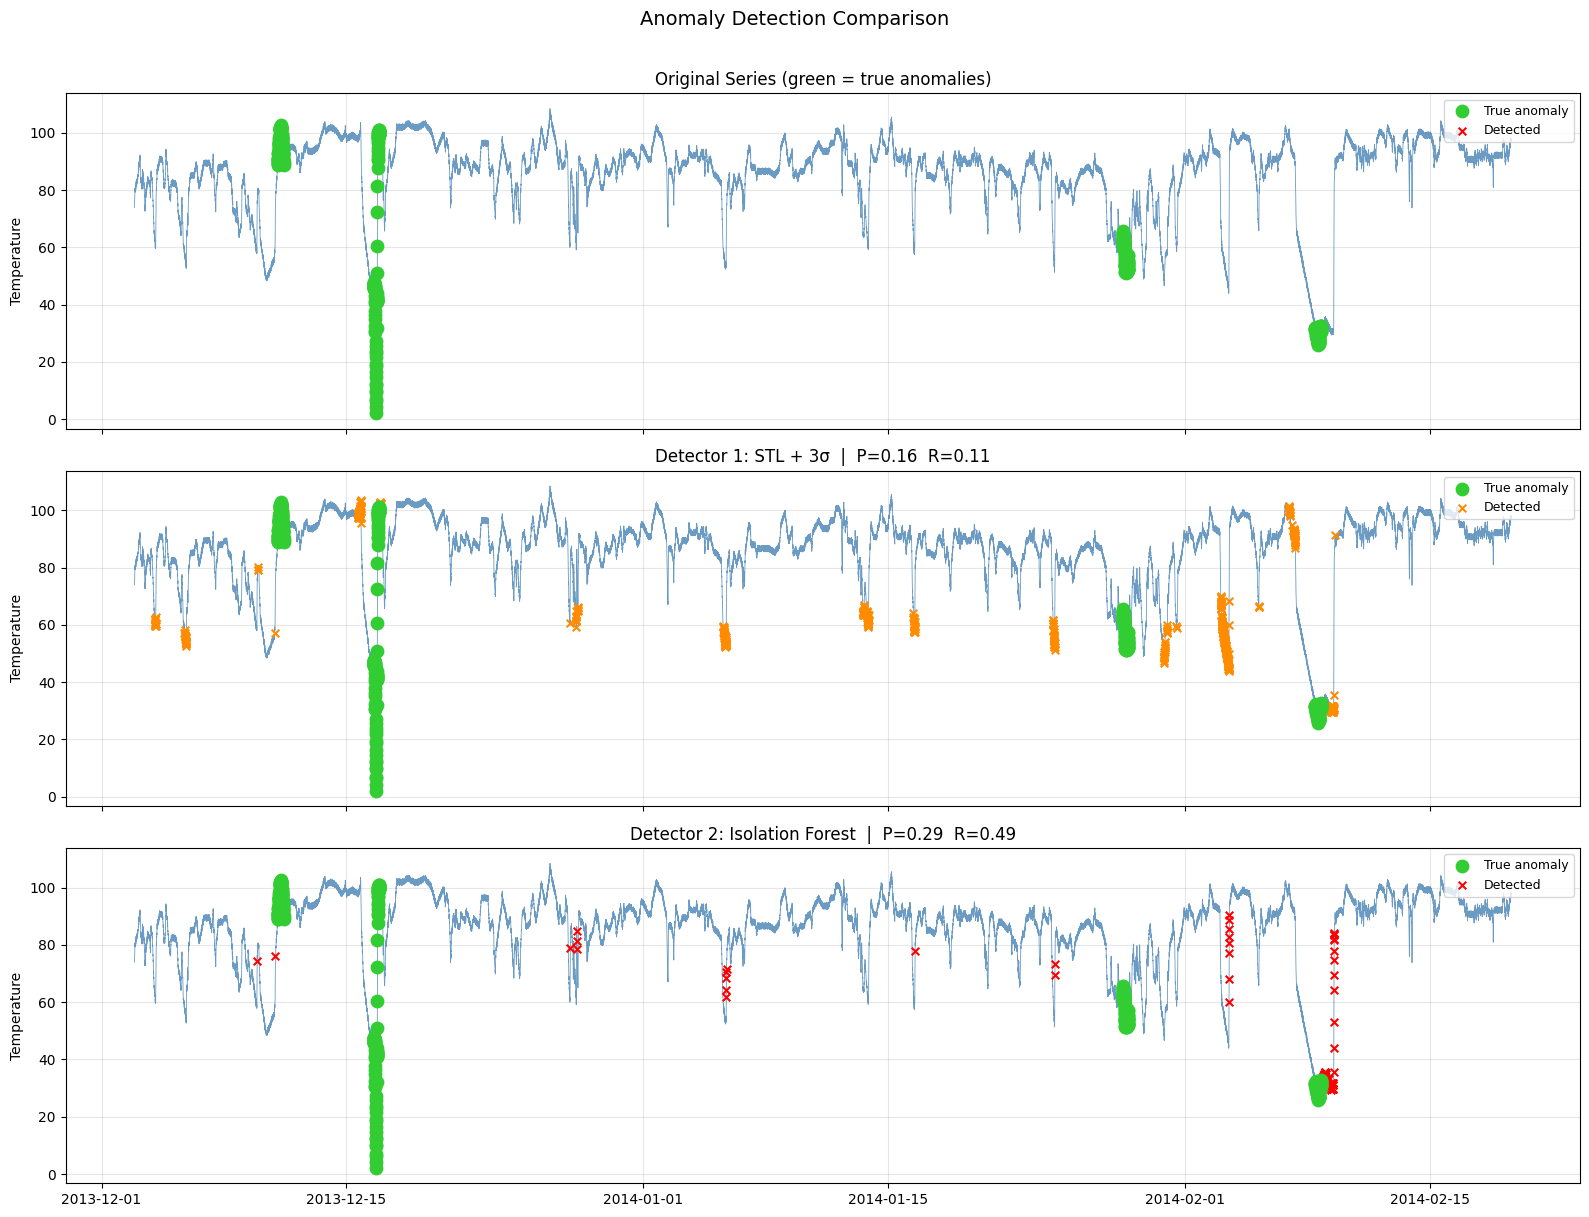

 Đã lưu: plot_comparison.png


In [38]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Màu sắc
COLOR_SERIES  = 'steelblue'
COLOR_TRUE    = 'limegreen'
COLOR_DETECT  = 'red'

def plot_detector(ax, title, anomaly_mask, color='red'):
    ax.plot(df.index, df['value'], color=COLOR_SERIES, linewidth=0.6, alpha=0.8)
    # Ground truth (xanh lá)
    true_pts = df[df['is_anomaly'] == 1]
    ax.scatter(true_pts.index, true_pts['value'],
               color=COLOR_TRUE, s=80, zorder=6, label='True anomaly', marker='o')
    # Detected (đỏ)
    det_pts = df[anomaly_mask]
    ax.scatter(det_pts.index, det_pts['value'],
               color=color, s=30, zorder=5, label='Detected', marker='x', linewidths=1.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Temperature')
    ax.legend(loc='upper right', fontsize=9)

# Panel 1: Raw series + true anomalies
plot_detector(axes[0], 'Original Series (green = true anomalies)',
              np.zeros(len(df), dtype=bool))  # no detection, just show true

# Panel 2: STL detector
p1 = metrics_stl['precision']
r1 = metrics_stl['recall']
plot_detector(axes[1],
              f'Detector 1: STL + 3σ  |  P={p1:.2f}  R={r1:.2f}',
              stl_anomalies.values, color='darkorange')

# Panel 3: Isolation Forest
p2 = metrics_if['precision']
r2 = metrics_if['recall']
plot_detector(axes[2],
              f'Detector 2: Isolation Forest  |  P={p2:.2f}  R={r2:.2f}',
              if_anomalies, color='red')

plt.suptitle('Anomaly Detection Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Đã lưu: plot_comparison.png')

---
## Phase 3: So Sánh & Reflection

### Cell 13 — Bảng so sánh tổng hợp

In [39]:
comparison = pd.DataFrame([
    {
        'Detector'     : 'STL + 3σ',
        'Precision'    : round(metrics_stl['precision'], 3),
        'Recall'       : round(metrics_stl['recall'], 3),
        'F1'           : round(metrics_stl['f1'], 3),
        'False Alarms' : metrics_stl['fp'],
        'Missed'       : metrics_stl['fn'],
    },
    {
        'Detector'     : f'Isolation Forest (cont={BEST_CONTAMINATION})',
        'Precision'    : round(metrics_if['precision'], 3),
        'Recall'       : round(metrics_if['recall'], 3),
        'F1'           : round(metrics_if['f1'], 3),
        'False Alarms' : metrics_if['fp'],
        'Missed'       : metrics_if['fn'],
    },
])

print('\n' + '=' * 70)
print('                  BẢNG SO SÁNH 2 DETECTOR')
print('=' * 70)
print(comparison.to_string(index=False))
print('=' * 70)

# Nhận xét tự động
print('\nNHẬN XÉT:')
if metrics_stl['recall'] > metrics_if['recall']:
    print('  → STL + 3σ có Recall cao hơn: bắt được nhiều anomaly thật hơn')
else:
    print('  → Isolation Forest có Recall cao hơn: bắt được nhiều anomaly thật hơn')

if metrics_stl['precision'] > metrics_if['precision']:
    print('  → STL + 3σ có Precision cao hơn: ít false alarm hơn')
else:
    print('  → Isolation Forest có Precision cao hơn: ít false alarm hơn')

winner = 'STL + 3σ' if metrics_stl['f1'] > metrics_if['f1'] else 'Isolation Forest'bb
print(f'  → Theo F1: {winner} tốt hơn trong bài toán này')
print('\n  Production choice: STL + 3σ làm first-pass (recall cao, bắt rộng)')
print('  + Isolation Forest làm second-pass filter (loại false alarm)')


                  BẢNG SO SÁNH 2 DETECTOR
                    Detector  Precision  Recall    F1  False Alarms  Missed
                    STL + 3σ      0.165   0.107 0.130           324     534
Isolation Forest (cont=0.01)      0.286   0.489 0.361           277     116

NHẬN XÉT:
  → Isolation Forest có Recall cao hơn: bắt được nhiều anomaly thật hơn
  → Isolation Forest có Precision cao hơn: ít false alarm hơn
  → Theo F1: Isolation Forest tốt hơn trong bài toán này

  Production choice: STL + 3σ làm first-pass (recall cao, bắt rộng)
  + Isolation Forest làm second-pass filter (loại false alarm)


In [44]:
print(f'Score min:  {scores.min():.4f}')
print(f'Score max:  {scores.max():.4f}')
print(f'Score mean: {scores.mean():.4f}')
print(f'Percentile 1%:  {np.percentile(scores, 1):.4f}')
print(f'Percentile 5%:  {np.percentile(scores, 5):.4f}')
print(f'Percentile 10%: {np.percentile(scores, 10):.4f}')

# Thử threshold dựa trên percentile thay vì giá trị cứng
for pct in [1, 2, 3, 5, 8, 10]:
    thresh = np.percentile(scores, pct)
    preds = (scores < thresh).astype(int)
    TP = np.sum((preds == 1) & (y_true == 1))
    FP = np.sum((preds == 1) & (y_true == 0))
    FN = np.sum((preds == 0) & (y_true == 1))
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    print(f'percentile={pct:>2}%  thresh={thresh:.4f}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}  alerts={preds.sum()}')

Score min:  -0.0765
Score max:  0.3007
Score mean: 0.2178
Percentile 1%:  -0.0000
Percentile 5%:  0.1015
Percentile 10%: 0.1365
percentile= 1%  thresh=-0.0000  P=0.489  R=0.286  F1=0.361  alerts=227
percentile= 2%  thresh=0.0203  P=0.315  R=0.369  F1=0.340  alerts=454
percentile= 3%  thresh=0.0671  P=0.219  R=0.384  F1=0.279  alerts=681
percentile= 5%  thresh=0.1015  P=0.158  R=0.461  F1=0.235  alerts=1135
percentile= 8%  thresh=0.1234  P=0.113  R=0.531  F1=0.187  alerts=1816
percentile=10%  thresh=0.1365  P=0.103  R=0.601  F1=0.175  alerts=2270


### Cell 14 — Tune log (ghi lại kết quả tuning)
Đây là bằng chứng bạn đã tune threshold / contamination.

In [40]:
print('TUNING LOG — Isolation Forest contamination:')
print(f'{"Run":>4}  {"contamination":>15}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}  {"FP":>6}')
print('─' * 60)
for i, r in enumerate(tune_results, 1):
    marker = ' ← BEST' if r['contamination'] == BEST_CONTAMINATION else ''
    print(f'{i:>4}  {r["contamination"]:>15.3f}  {r["precision"]:>10.3f}  '
          f'{r["recall"]:>8.3f}  {r["f1"]:>8.3f}  {r["fp"]:>6}{marker}')

# Cũng tune STL threshold
print('\nTUNING LOG — STL threshold (3σ):')
print(f'{"Run":>4}  {"threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}')
print('─' * 48)
for thresh in [2.0, 3.0, 4.0]:
    stl_tmp = np.abs(residual - resid_mean) > thresh * resid_std
    y_tmp = stl_tmp.astype(int).values
    TP = np.sum((y_tmp == 1) & (y_true == 1))
    FP = np.sum((y_tmp == 1) & (y_true == 0))
    FN = np.sum((y_tmp == 0) & (y_true == 1))
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    marker = ' ← default' if thresh == 3.0 else ''
    run = int((thresh - 2.0) / 1.0) + 1
    print(f'{run:>4}  {thresh:>10.1f}  {prec:>10.3f}  {rec:>8.3f}  {f1:>8.3f}{marker}')

TUNING LOG — Isolation Forest contamination:
 Run    contamination   Precision    Recall        F1      FP
────────────────────────────────────────────────────────────
   1            0.010       0.489     0.286     0.361     116 ← BEST
   2            0.020       0.315     0.369     0.340     311
   3            0.050       0.158     0.461     0.235     956

TUNING LOG — STL threshold (3σ):
 Run   threshold   Precision    Recall        F1
────────────────────────────────────────────────
   1         2.0       0.077     0.335     0.125
   2         3.0       0.107     0.165     0.130 ← default
   3         4.0       0.139     0.059     0.083
